# PyTorch Custom Datasets Notebook

Resources:
[Zero to Mastery book](https://www.learnpytorch.io/)


## 1.Domain libraries
Depending on what you're working on, vision, text, audio, recommendation, you'll want to look into each of the PyTorch existing data loading fucntions and customizable data loading functions.😁

## 2.Importing PyTorch and setting up device-agnostic code

In [1]:
import torch
from torch import nn

torch.__version__

'2.10.0+cpu'

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## 3.Get data

Our database is a subset of the Food101 dataset.

The whole point is to speed up the process

In [ ]:
import requests
import zipfile
from pathlib import Path

# Setup path to a data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
    print(f"{image_path} directory already exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

# Download pizza, steak and sushi data
with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
    # Corrected URL to get the raw zip file content
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/data/pizza_steak_sushi.zip")
    print("Downloading pizza, steak, sushi data...")
    f.write(request.content)

    # Unzip file
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip","r") as zip_ref:
      print("Unzfipping file...")
      zip_ref.extractall(image_path)

    # Remove zip file
    print("Removing zip file...")
    !rm {data_path / "pizza_steak_sushi.zip"}

Did not find data/pizza_steak_sushi directory, creating one...
Unzfipping file...
Removing zip file...


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 4.Becoming one with the data (data preparaation and data exploration)

In [ ]:
import os

def walk_through_dir(dir_path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

walk_through_dir(image_path)


There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.


In [ ]:
# Setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir


(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

### 4.1 Visualizing and image

Let's write some code to:
1. Get all of the image paths
2. Pick a random image path using Python's random choice()
3. Get the image class name using `pathlib.Path.parent.stem`
4. Since we're working with images, lets open the image with Python's PIL
5. We'll then show the image and print metadata

steak

Image metadata:

Random image path: data/pizza_steak_sushi/train/steak/2614649.jpg

Image class: steak

Width, height: (384, 512)

Image format: JPEG


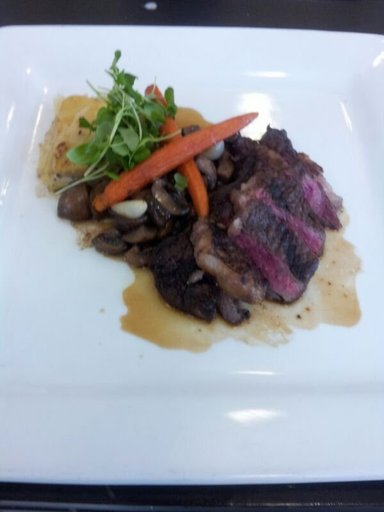

In [ ]:
import random
from PIL import Image

# Set seed
# random.seed(42)

# 1. Get all image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))

# 2. Randomly select a image path
random_image_path = random.choice(image_path_list)

random_image_path

# 3. Get image class from path name (the image class is name of the directory where the image is stored)
image_class = random_image_path.parent.stem
print(image_class)

# 4. Open image
img = Image.open(random_image_path)


# 5. Print metadata
print("\nImage metadata:")
print(f"\nRandom image path: {random_image_path}")
print(f"\nImage class: {image_class}")
print(f"\nWidth, height: {img.size}")
print(f"\nImage format: {img.format}")
img

(np.float64(-0.5), np.float64(383.5), np.float64(511.5), np.float64(-0.5))

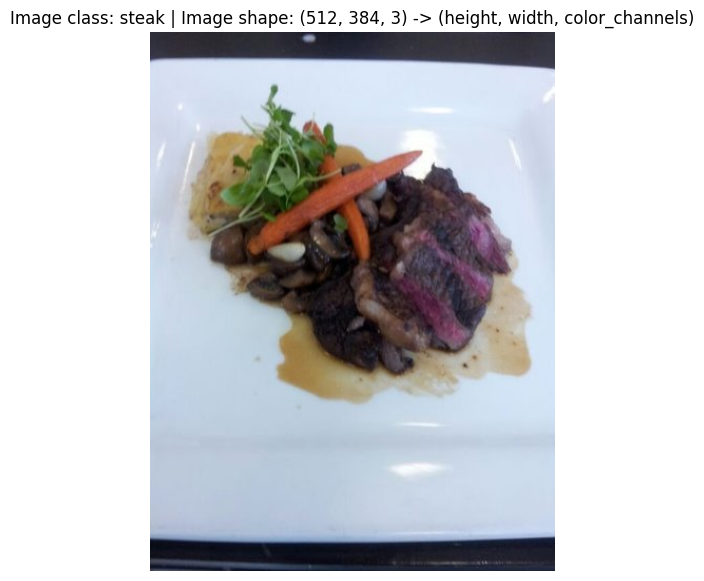

In [ ]:
# Visulize image with matplot lib
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_arr = np.asarray(img)

# Plot the image with matplotlib
plt.figure(figsize=(10,7))
plt.imshow(img_as_arr)
plt.title(f"Image class: {image_class} | Image shape: {img_as_arr.shape} -> (height, width, color_channels)")
plt.axis(False)

array([[[47, 47, 57],
        [47, 47, 57],
        [47, 47, 57],
        ...,
        [51, 51, 61],
        [50, 50, 62],
        [50, 50, 62]],

       [[48, 48, 58],
        [48, 48, 58],
        [47, 47, 57],
        ...,
        [53, 53, 63],
        [53, 53, 65],
        [52, 52, 64]],

       [[49, 49, 59],
        [49, 49, 59],
        [48, 48, 58],
        ...,
        [54, 54, 66],
        [54, 54, 66],
        [54, 54, 66]],

       ...,

       [[38, 41, 58],
        [38, 41, 58],
        [38, 41, 58],
        ...,
        [38, 43, 63],
        [38, 43, 63],
        [38, 43, 63]],

       [[55, 58, 75],
        [55, 58, 75],
        [57, 60, 77],
        ...,
        [32, 38, 60],
        [32, 38, 60],
        [32, 38, 60]],

       [[59, 62, 79],
        [60, 63, 80],
        [64, 67, 84],
        ...,
        [27, 33, 55],
        [27, 33, 55],
        [27, 33, 55]]], dtype=uint8)
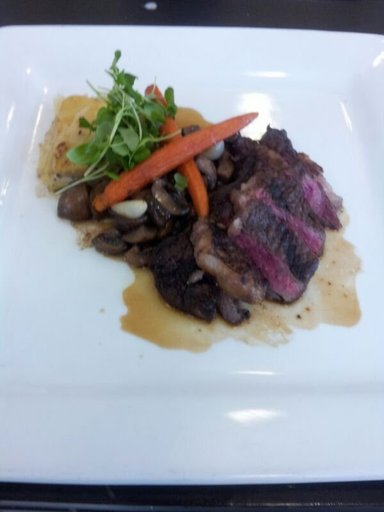

In [ ]:
img_as_arr

## 5.Transforming data
Before we can use our image data with PyTorch:
1. Turn our target into tensors
2. Turn it into a `torch.utils.data.Dataset` and subsequently a `torch.utils.data.DataLoader`, we'll call these *Dataset* and *DataLoader*

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### 5.1 Transforming data with `torchvision.transforms`

*`Transforms` helps getting images ready to be used with a model/perform data augmentation*

[Transform](https://docs.pytorch.org/vision/stable/transforms.html)

In [ ]:
# Write a transform for image
data_transform = transforms.Compose([
    # Resize our images to 64x64
    transforms.Resize((64,64)),
    # Flip the images randomly  on the horizontal
    transforms.RandomHorizontalFlip(p=0.5),
    # Turn the image into a toch tensor
    transforms.ToTensor()
])

In [ ]:
data_transform(img).shape

torch.Size([3, 64, 64])

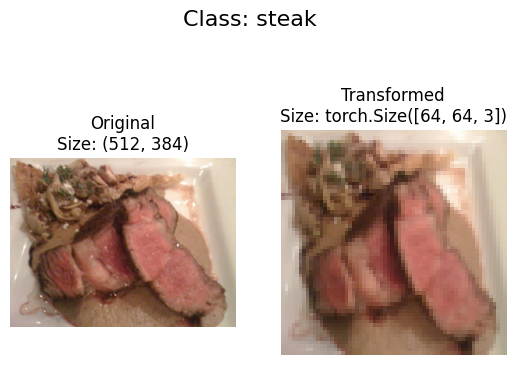

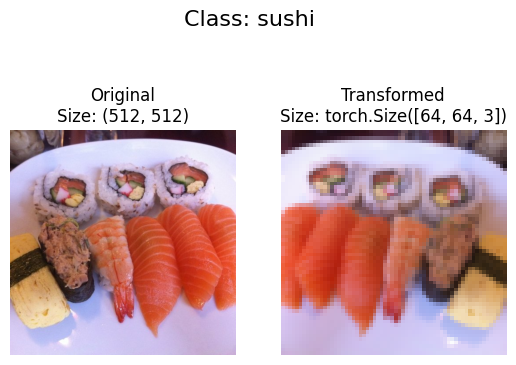

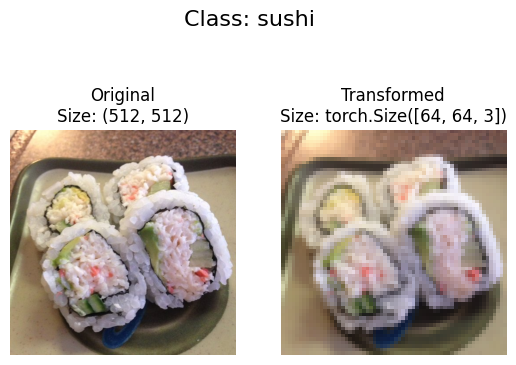

In [ ]:
def plot_transformed_images(image_paths,
                            transform,
                            n=3,
                            seed=None):
  if seed:
    random.seed(seed)
  random_image_paths = random.sample(image_paths, k=n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(1,2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original\nSize: {f.size}")
      ax[0].axis(False)

      # Transform and plot the target image
      transformed_image = transform(f).permute(1,2,0) # Swap the order of color channel
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"Transformed\nSize: {transformed_image.shape}")
      ax[1].axis(False)

      fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_paths=image_path_list,
                        transform=data_transform,
                        n=3,
                        seed=42)


## 6.Option 1: Loading image data using `Image folder`

We can load image classfication data using `torchvision.datasets.ImageFolder`
[Image Folder](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html)



In [ ]:
# Use ImageFolder to create dataset
from torchvision import datasets

train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform, # A transform for the data
                                  target_transform=None) # A transform for the labels

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [ ]:
# Get class names as a list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [ ]:
# Get class names as a dictionary
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [ ]:
# Check the length of our dataset
len(train_data), len(test_data)

(225, 75)

In [ ]:
train_data.samples[0]

('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0)

In [ ]:
# Index on the train_data Dataset to get a single image and label
img,label = train_data[0][0], train_data[0][1]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image label: {label} ({class_names[label]}")
print(f"Image datatype: {img.dtype}")
print(f"Image class: {type(img)}")


Image tensor:
tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
         [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
         [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
         ...,
         [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
         [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
         [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],

        [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
         [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
         [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
         ...,
         [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
         [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
         [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],

        [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
         [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
         [0.0902, 0.0902, 0.0902,  ..., 0.01

In [ ]:
class_names[label]

'pizza'

Original shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Permuted shape: torch.Size([64, 64, 3]) -> [height, width, color_channels]


Text(0.5, 1.0, '(pizza)')

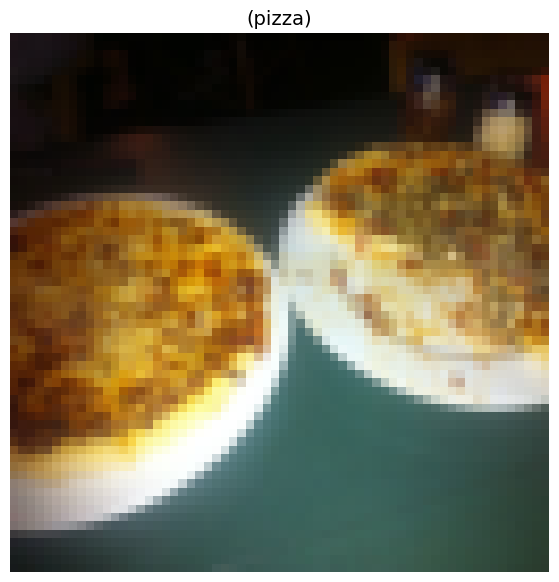

In [ ]:
# Rearrange the order of dimensions
img_permute = img.permute(1,2,0)

# Print out different shapes
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Permuted shape: {img_permute.shape} -> [height, width, color_channels]")

# Plot the image
plt.figure(figsize=(10,7))
plt.imshow(img.permute(1,2,0))
plt.axis(False)
plt.title(f"({class_names[label]})", fontsize=14)

### 6.1 Turn loaded images into `DataLoader's`

A data loader is going to help us turn our Datasets's iterables and we can customise the `batch_size` so out model can see `batch_size` images at a time


In [ ]:
import os
os.cpu_count()

2

In [ ]:
# Turn train and test datasets into DataLoader's
from torch.utils.data import DataLoader

BATCH_SIZE = 1
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=os.cpu_count(),
                              shuffle=True) # Shuffle the data(we don't want our model to recognise order of the data)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size = BATCH_SIZE,
                             num_workers=os.cpu_count(),
                             shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7e630dcbb680>,
 <torch.utils.data.dataloader.DataLoader at 0x7e630de4f8f0>)

In [ ]:
len(train_dataloader), len(test_dataloader)

(225, 75)

In [ ]:
img, label = next(iter(train_dataloader))

# Batch size will now be 1
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([1, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([1])


## 7.Option 2: Loading Image Data with a Custom `Dataset`

1. Want to be able to load images from file
2. Want ot be able to get class names from the Dataset
3. Want to be able to get classes as dictionary from Dataset

***Pros***:
* Can create a `Dataset` out of almost anything
* Not limited to PyTorch pre-built `Dataset` functions

***Cons***:
* Even though you could create `Dataset` out of almost anything, it doesn't mean it will work..
* Using custom `Dataset` often results in us writting more code that often means prone to errors or performance issues


*All custom datasets in PyTorch often subclass this: https://docs.pytorch.org/vision/main/datasets.html*

In [ ]:
import os
import pathlib
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [ ]:
# Instance of torchvision.datasets.ImageFolder()
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 7.1 Create a helper function to get class names
 We want a function to:
 1. Get the class names using `os.scandir` to traverse a target directory
 2. Raise an error if the class names aren't found
 3. Turn the class names into a dict and a list and return them

In [ ]:
# Setup path for target directory
target_directory = train_dir
print(f"Target directory: {target_directory}")

# Get the class names from the target directory
class_names = sorted([entry.name for entry in list(os.scandir(target_directory))])

Target directory: data/pizza_steak_sushi/train


In [ ]:
list(os.scandir(target_directory))

[<DirEntry 'sushi'>, <DirEntry 'pizza'>, <DirEntry 'steak'>]

In [ ]:
# Create function that finds classes in directory
def find_classes(directory:str) -> Tuple[List[str], Dict[str,int]]:
  """Finds the class folder names in a target directory"""

  # 1. Get the class names by scanning the target directory
  classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

  # 2. Raise an error if class names not found
  if not classes:
    raise FileNotFoundError(f"Couldn't find any classes in {directory}")

  # 3. Create a dictionary of index labels
  class_to_idx = {class_name: i for i, class_name in enumerate(classes)}
  return classes, class_to_idx

In [ ]:
find_classes(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 7.2 Create a custom `Dataset` to replicate `ImageLoader`
To create our custom dataset, we want to:
1. Subclass `torch.utils.data.Dataset`
2. Init our with a target directory as well as a transform if we'd like to transform our data
3. Create several attributes:
  * paths - paths of our images
  * transform - the transform we'd like to use
  * classes - a list of the target classes
  * class_to_idx - a dict of the target classes mapped to integer labels
4. Create a function to `load_images()`, this function will open an image
5. Overwrite the `__len__` method to return the length of our dataset
6. Overwrite the `__get_item()__` method to return a given sample when passed an index


In [ ]:
# 0. Write a custom dataset class
from torch.utils.data import Dataset
# 1. Subclass torch.utils.data.Dataset
class ImageFolderCustom(Dataset):
  # 2. Initialize our custom dataset
  def __init__(self,
               targ_dir:str,
               transform=None):

    # 3. Create class attributes
    # Get all of the image paths
    self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
    # Setup transforms
    self.transform = transform
    # Create classes and class_to_idx attributes
    self.classes, self.class_to_idx = find_classes(targ_dir)

  # 4. Create a function to load images
  def load_image(self,index:int) -> Image.Image:
    "Opens and returns an image based on an index."
    image_path = self.paths[index]
    return Image.open(image_path)

  # 5. Overwrite the len method
  def __len__(self) -> int:
    """Returns the total number of samples."""
    return len(self.paths)

  # 6. Overwrite _getitem()_ method to return a partcular sample
  def __getitem__(self,index:int) -> Tuple[torch.Tensor,int]:
    "Returns one sample of data, data and label(target)."
    image = self.load_image(index)
    class_name = self.paths[index].parent.name # expects path in format: data_folder/class/class_name/image.jpg
    class_idx = self.class_to_idx[class_name]

    # 7. Transform if necessary
    if self.transform:
      return self.transform(image), class_idx # return data, label (X,y)
    else:
      return image, class_idx # return untransformed image and label

In [ ]:
# Create a transform
from torchvision import transforms
train_transforms = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])
test_transforms = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

In [ ]:
# Test out ImageFolderCustom
train_data_custom = ImageFolderCustom(targ_dir=train_dir,
                                      transform=train_transforms)

test_data_custom = ImageFolderCustom(targ_dir=test_dir,
                                     transform=test_transforms)

In [ ]:
len(train_data_custom), len(train_data_custom)

(225, 225)

In [ ]:
len(test_data_custom), len(test_data_custom)

(75, 75)

In [ ]:
train_data_custom.classes, train_data_custom.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [ ]:
# Check for equility between original ImageFolder and ImageCustomDataset
print(f"Test Data Equality: {train_data_custom.classes == train_data.classes}")
print(f"Train Data Equality Equality: {train_data_custom.classes == train_data.classes}")


Test Data Equality: True
Train Data Equality Equality: True


### 7.3 Create a function to display random images

1. Take in a `Dataset` and a number of other parameters such as class names and how many images to visualize
2. To prevent the display getting out of hand, let's cap the number of images to see at 10
3. Set the random seed for reproducibility
4. Get a list of random sample indexes from the target dataset
5. Setup a matplotlib
6. Look through the random sample images and split them with matplotlib
7. Make sure the dimensions of our images line up with matplotlib (HWC)


In [ ]:
random.sample(range(len(train_data_custom)),k=10)

[62, 57, 35, 188, 26, 173, 189, 139, 22, 151]

In [ ]:
# 1. Create a function to take in a dataset
def display_random_images(dataset:torch.utils.data.Dataset,
                          classes:List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):
# 2. Adjust display of n is too high
  if n > 10:
    n = 10
    display_shape = False
    print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.")

# 3. Set the random seed
  if seed:
    random.seed(seed)

# 4. Get random smaple indexes
  random_samples_idx = random.sample(range(len(dataset)),k=n)

# 5. Setup plot
  plt.figure(figsize=(16,8))

# 6. Loop through random indexes and plot them with matplotlib
  for i, targ_sample in enumerate(random_samples_idx):
    targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1] # image and label

# 7. Adjust tensor dimensions for plotting
    targ_image_adjust = targ_image.permute(1,2,0) # HWC -> CHW (Color channels)

# 8. Plot adjusted samples
    plt.subplot(1,n,i+1) # 1 row of n images
    plt.imshow(targ_image_adjust)
    if classes:
      title = f"Class: {classes[targ_label]}"
      if display_shape:
        title +=  f"\nshape: {targ_image_adjust.shape}\n"
    plt.axis(False)
    plt.title(title)

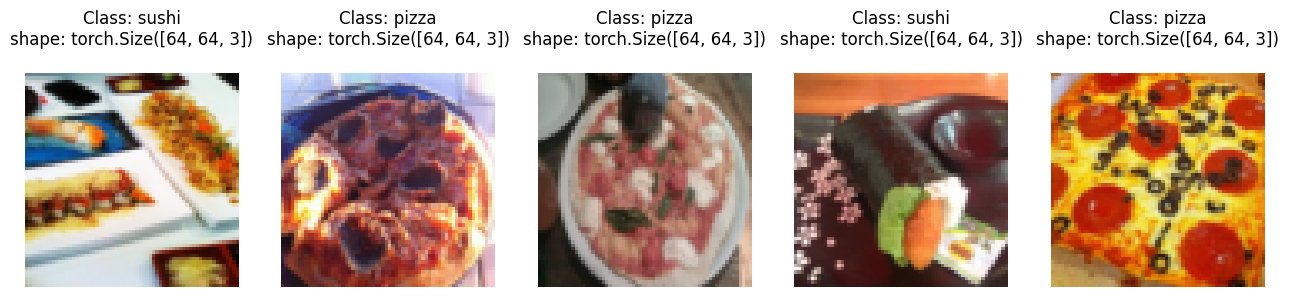

In [ ]:
# Display random images from the ImageFolder created Dataset
display_random_images(dataset=train_data,
                      classes=class_names,
                      n=5,
                      seed=42)

For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.


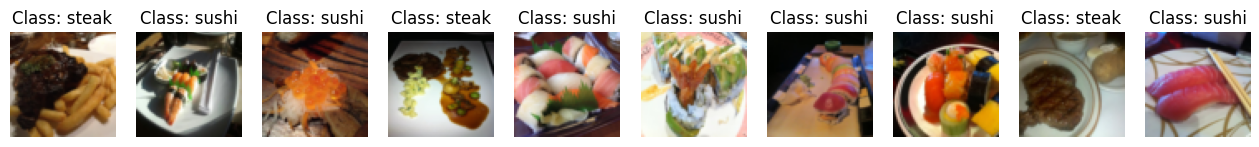

In [ ]:
# Display random images from ImageFolderCustom Dataset
display_random_images(train_data_custom,
                      classes=class_names,
                      n=20,
                      seed=42)

### 7.4 Turn custom loaded images into `DataLoader's`

In [ ]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

train_dataloader_custom = DataLoader(dataset=train_data_custom,
                                     batch_size=BATCH_SIZE,
                                     num_workers=NUM_WORKERS,
                                     shuffle=True)

test_dataloader_custom = DataLoader(dataset=test_data_custom,
                                    batch_size=BATCH_SIZE,
                                    num_workers=NUM_WORKERS,
                                    shuffle=False)

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x7e630c3bc7d0>,
 <torch.utils.data.dataloader.DataLoader at 0x7e630c3f3110>)

In [ ]:
# Get image and label from custom dataloader
img_custom, label_custom = next(iter(train_dataloader_custom))

# Print out the shapes
img_custom.shape, label_custom.shape


(torch.Size([32, 3, 64, 64]), torch.Size([32]))

## 8.Other forms of transforms (data augmentation)

*Techniques used to increase the amount of data by adding slighly modified copies of already existing sata ot newly created synthetic data from existing one*

*The idea is our model to learn better finding image patterns*

[Blog Post](https://pytorch.org/blog/how-to-train-state-of-the-art-models-using-torchvision-latest-primitives/)

In [ ]:
# Let's look at TrivialAugment
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),# How intense we want an augmentation to happen. From 0 -> 31
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_transform, test_transform


(Compose(
     Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
     TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
     ToTensor()
 ),
 Compose(
     Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
     ToTensor()
 ))

In [ ]:
# Get all image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[PosixPath('data/pizza_steak_sushi/test/sushi/684266.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/988559.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/1245193.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/2741434.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/3806282.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/3837522.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/175783.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/3196729.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/499605.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/46797.jpg')]

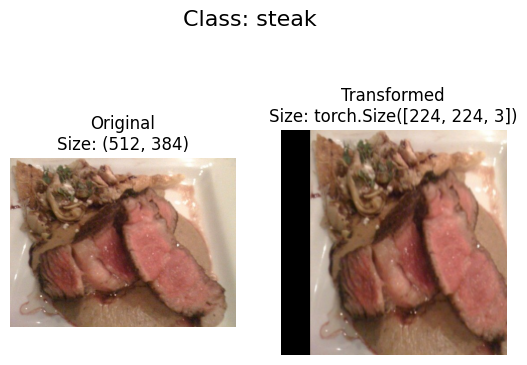

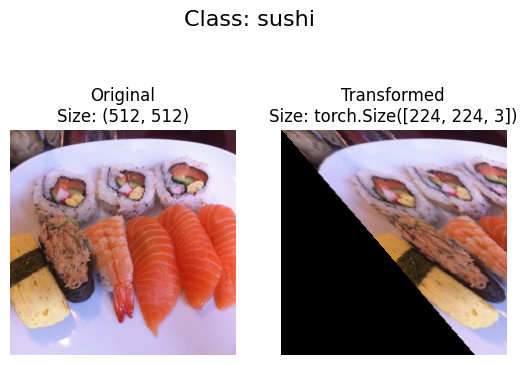

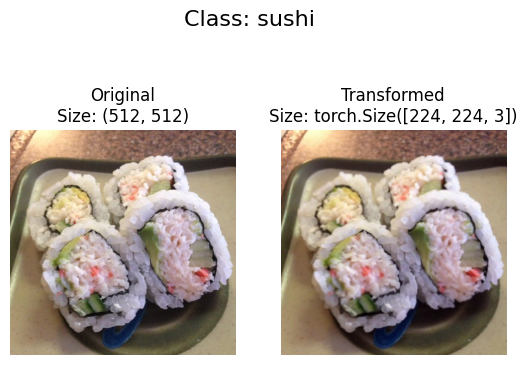

In [ ]:
# Plot random transformed images

plot_transformed_images(
    image_paths=image_path_list,
    transform=train_transform,
    n=3,
    seed=42
)

## 9.Model 0: TinyVGG without data augmentation

Let's replicate TinyVGG architecture from the CNN Explainer website

### 9.1 Creating transforms and loading data for Model 0

In [ ]:
# Create simple transform
simple_transform = transforms.Compose([transforms.Resize((64,64)),
                                        transforms.ToTensor()])

#  1. Load and transform data
from torchvision import datasets
from torch.utils.data import DataLoader

train_data_simple = datasets.ImageFolder(root=train_dir,
                                  transform=simple_transform,
                                  target_transform=None)

test_data_simple = datasets.ImageFolder(root=test_dir,
                                        transform=simple_transform)

# Turn the datasets into DataLoader
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

train_dataloader_simple = DataLoader(dataset = train_data_simple,
                                       batch_size=BATCH_SIZE,
                                       num_workers=NUM_WORKERS,
                                       shuffle=True)

test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    num_workers=NUM_WORKERS,
                                    shuffle=False)

train_dataloader_simple, test_dataloader_simple

(<torch.utils.data.dataloader.DataLoader at 0x7e630c87c590>,
 <torch.utils.data.dataloader.DataLoader at 0x7e630c87ed80>)

### 9.2 Create TinyVGG model class

In [ ]:
class TinyVGG(nn.Module):
  """Creates the TinyVGG architecture.
  Replicates the TinyVGG architecture from the CNN Explainer website"""
  def __init__(self,
               input_shape = int,
               hidden_units = int,
               output_shape = int) -> None:
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels = hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2) # default stride value is same as the kernel size
    )

    self.conv_block_2 = nn.Sequential(
      nn.Conv2d(in_channels=hidden_units,
                  out_channels = hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
      nn.ReLU(),
      nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2,
                     stride=2) # default stride value is same as the kernel size
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*13*13,
                  out_features=output_shape)
    )
  def forward(self,x):
    x = self.conv_block_1(x)
    # print(f"Shape before flattening: {x.shape}")
    x = self.conv_block_2(x)
    # print(f"Shape after flattening: {x.shape}")
    x = self.classifier(x)
    return x
    #return self.classifier(self.conv_block_2(self.conv_block_1(x))) # Benefits from operator fusion

In [ ]:
# Make an instance of our model
torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(class_names)).to(device)
model_0


TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

### 9.3 Try a forward pass on a single image (to test the model)

In [ ]:
# Get a single image batch
image_batch, label_batch = next(iter(train_dataloader_simple))

# Single image batch
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [ ]:
# Try a forward pass
model_0(image_batch.to(device))

tensor([[ 2.0795e-02, -1.9510e-03,  9.5212e-03],
        [ 1.8440e-02,  2.4668e-03,  6.6609e-03],
        [ 1.7695e-02,  1.0282e-03,  9.4975e-03],
        [ 2.4446e-02, -3.3489e-03,  9.5877e-03],
        [ 1.9939e-02,  6.9131e-04,  1.0778e-02],
        [ 2.1281e-02,  2.0434e-03,  5.0046e-03],
        [ 2.0996e-02,  1.6415e-04,  1.2481e-02],
        [ 2.1566e-02, -1.9607e-03,  9.7175e-03],
        [ 2.4500e-02, -4.7904e-03,  8.5394e-03],
        [ 2.0239e-02, -4.7979e-04,  1.0907e-02],
        [ 2.2219e-02, -4.1816e-04,  9.8173e-03],
        [ 2.2318e-02, -2.1642e-03,  9.4428e-03],
        [ 2.1851e-02, -3.7225e-03,  8.3784e-03],
        [ 2.2881e-02, -1.7559e-03,  1.0299e-02],
        [ 2.1635e-02, -4.3995e-03,  9.4990e-03],
        [ 2.2101e-02, -4.1469e-03,  9.3904e-03],
        [ 2.1226e-02, -4.4215e-03,  1.1476e-02],
        [ 2.1698e-02, -2.7458e-03,  8.4966e-03],
        [ 1.9974e-02, -3.1665e-07,  8.4496e-03],
        [ 1.8308e-02,  1.6378e-03,  8.5491e-03],
        [ 2.0768e-02

### 9.4 `torchinfo` to get an idea what's going through our model

In [ ]:
try:
  import torchinfo
except:
  !pip install torchinfo
  import torchinfo

from torchinfo import summary
summary(model_0,input_size=[1,3,64,64])


Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─ReLU: 2-4                         [1, 10, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 28, 28]           910
│    └─ReLU: 2-7                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 10, 26, 26]           910
│    └─ReLU: 2-9                         [1, 10, 26, 26]           --
│    └─MaxPool2d: 2-10                   [1, 10, 13, 13]           --
├─Sequentia

### 9.5 Create train and test loops functions
* `train_step()` - takes in a model and dataloader and trains the model on the dataloader
* `test_step()` - takes in a model dataloader and evaluates the model on the dataloader


In [ ]:
# Create train_step()
def train_step(model:torch.nn.Module,
               dataloader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               device:torch.device = device):
  # Put the model in train mode
  model.train()

  # Setup train loss and acc values
  train_loss,train_acc = 0,0

  # Loop through data loader data batches
  for batch,(X,y) in enumerate(dataloader):
    # Send data to target device
    X,y = X.to(device), y.to(device)

    # 1. Forward pass
    y_pred = model(X) # Outputs model logits

    # 2. Calc loss
    loss = loss_fn(y_pred,y)
    train_loss += loss.item()

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    # 6. Calculate the accuracy
    y_pred_class = torch.argmax(torch.softmax(y_pred,dim=1),dim=1) # Transform logits to labels
    train_acc += (y_pred_class == y).sum().item()/len(y_pred)

# Adjust metrics to get the avg loss and accuracy per batch
  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)

  return train_loss, train_acc

In [ ]:
# Create test_step
def test_step(model:torch.nn.Module,
              dataloader = torch.utils.data.DataLoader,
              loss_fn=torch.nn.Module,
              device = device):
  # Put model in eval mode
  model.eval()
  # Setup test loss and test accuracy values
  test_loss, test_acc = 0,0 # Corrected: test_lossm -> test_loss, tes_acc -> test_acc
  # Turn on inference mode
  with torch.inference_mode():
    # Loop through DataLoder batches
    for batch,(X,y) in enumerate(dataloader):

    # 1. Foraward pass
      test_pred_logits = model(X)

    # 2. Calculate the loss
      loss = loss_fn(test_pred_logits,y)
      test_loss += loss.item()

    # Calculate the accuracy
      test_pred_labels = test_pred_logits.argmax(dim=1) # Corrected: test_pred_labels used before defined
      test_acc += (test_pred_labels == y).sum().item()/len(test_pred_labels)

  # Adjust the meterics to get avg loss and accuracy per batch
  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)

  return test_loss, test_acc

In [ ]:
from tqdm.auto import tqdm

# Create train function that combines train and test upper functions that takes in various model parameters
def train(model=torch.nn.Module,
          train_dataloader=torch.utils.data.DataLoader,
          test_dataloader=torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          optimizer=torch.optim.Optimizer,
          epochs = 5,
          device:torch.device = device):

  # 2. Create empty result dictionary
  results = {"train_loss":[],
             "train_acc":[],
             "test_loss":[],
             "test_acc":[]}

  # 3. Loop through training and testing steps for a number of epochs
  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model,train_dataloader,loss_fn,optimizer,device)
    test_loss, test_acc = test_step(model,test_dataloader,loss_fn,device)

    # 4. Print out what's happening
    print(
        f"Epoch: {epoch} | "
        f"train_loss: {train_loss:.4f} | "
        f"train_acc: {train_acc:.2f} | "
        f"test_loss: {test_loss:.4f} | "
        f"test_acc: {test_acc:.2f}")

    # 5. Update the results dictionary
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  # 6. Return the filled result at the end of the epochs
  return results

### 9.6 Train and evaluate model 0

In [ ]:
# Set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 5

# Recreate an instance of TinyVGG
model_0 = TinyVGG(
    input_shape=3,
    hidden_units=10,
    output_shape=len(train_data.classes)
)

# Setup loss funciton and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_0.parameters(),
                             lr=0.001)
# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_0
model_0_results = train(model=model_0,
                        train_dataloader=train_dataloader_simple,
                        test_dataloader=test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS,
                        device=device)

# End the timer and print how long it took
end_time = timer()
print(f"Total estimated training time: {end_time-start_time:.3f} seconds")


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | train_loss: 1.1063 | train_acc: 0.30 | test_loss: 1.0983 | test_acc: 0.30
Epoch: 1 | train_loss: 1.0998 | train_acc: 0.33 | test_loss: 1.0697 | test_acc: 0.54
Epoch: 2 | train_loss: 1.0869 | train_acc: 0.49 | test_loss: 1.0808 | test_acc: 0.49
Epoch: 3 | train_loss: 1.0842 | train_acc: 0.40 | test_loss: 1.0608 | test_acc: 0.58
Epoch: 4 | train_loss: 1.0662 | train_acc: 0.41 | test_loss: 1.0654 | test_acc: 0.56
Total estimated training time: 11.145 seconds


### 9.7 Plot the loss curves of Model 0

A ***loss-curve*** is a way of tracking a model progress over time

In [ ]:
# Get the model_0_result keys
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [ ]:
def plot_loss_curves(results:Dict[str,list[float]]):
  """Plots training curves of a results dictionary.

  Args:
      results (dict): dictionary"""
  loss = results["train_loss"]
  test_loss = results["test_loss"]

  accuracy = results["train_acc"]
  test_accuracy = results["test_acc"]

  epochs = range(len(results["train_loss"]))

  plt.figure(figsize=(15,7))

  # Plot the loss
  plt.subplot(1,2,1)
  plt.plot(epochs,loss,label="train_loss")
  plt.plot(epochs,test_loss,label="test_loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.legend()

  # Plot the accuracy
  plt.subplot(1,2,2)
  plt.plot(epochs,accuracy,label="train_accuracy")
  plt.plot(epochs,test_accuracy,label="test_accuracy")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.legend()

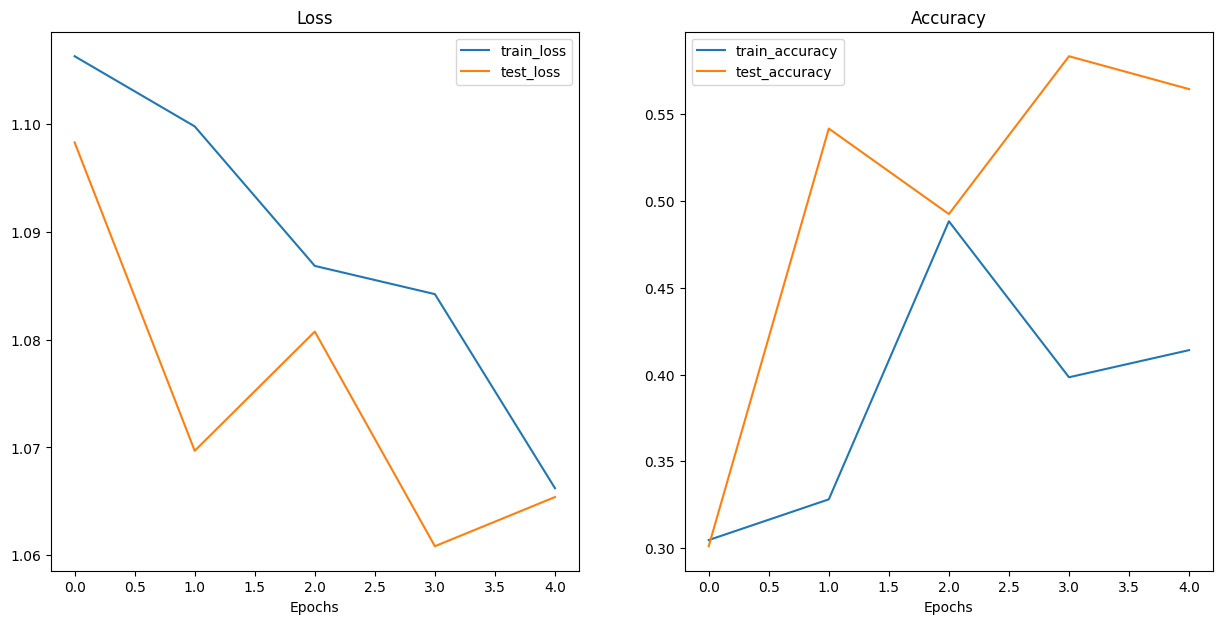

In [ ]:
plot_loss_curves(model_0_results)

## 10.What should an ideal loss curve look like?

*A loss curve is one of the most helpful ways to troubleshoot a model*

## 11.Model 1: TinyVGG with Data Augmentation


### 11.1 Create transform with data augmentation

In [ ]:
from torchvision import transforms
train_transform_trivial = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])
test_transform_simple = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

In [ ]:
###9.2 Create train and test datasets nad dataloaders with data augmentation
from torchvision import datasets
from torch.utils.data import DataLoader
 # Turn image folders into Datasets
train_data_augmented = datasets.ImageFolder(root=train_dir,
                                              transform=train_transform_trivial,
                                              target_transform=None)

test_data_augmented = datasets.ImageFolder(root=test_dir,
                                            transform=test_transform_simple)


In [ ]:
 # Turn our Datasets into DataLoaders
import os
BATCH_SIZE=32
NUM_WORKERS = os.cpu_count()

torch.manual_seed(42)
train_dataloader_augmented = DataLoader(dataset=train_data_augmented,
                                          batch_size=BATCH_SIZE,
                                          shuffle = True,
                                          num_workers=NUM_WORKERS)

test_dataloader_augmented = DataLoader(dataset=test_data_augmented,
                                        batch_size=BATCH_SIZE,
                                        shuffle =  False,
                                        num_workers=NUM_WORKERS)

### 11.2 Construct and train model 1

This time we'll be using the same architecture but we've augmented the training data



In [ ]:
# Create model_1
torch.manual_seed(42)
model_1 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_data_augmented.classes)).to(device)

model_1

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

In [ ]:
# Train our model_1
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS=5

losss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params=model_1.parameters(),
                             lr=0.001)

from timeit import default_timer as timer
start_timer = timer()

model_1_results = train(model=model_1,
                        train_dataloader=train_dataloader_augmented,
                        test_dataloader=test_dataloader_augmented,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS,
                        device=device)

end_time = timer()
print(f"Total training time for model_1: {end_time-start_time:.3f} seconds")



  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | train_loss: 1.1049 | train_acc: 0.25 | test_loss: 1.1019 | test_acc: 0.26
Epoch: 1 | train_loss: 1.0807 | train_acc: 0.43 | test_loss: 1.1261 | test_acc: 0.26
Epoch: 2 | train_loss: 1.0712 | train_acc: 0.43 | test_loss: 1.1593 | test_acc: 0.26
Epoch: 3 | train_loss: 1.1253 | train_acc: 0.30 | test_loss: 1.1581 | test_acc: 0.26
Epoch: 4 | train_loss: 1.0865 | train_acc: 0.43 | test_loss: 1.1554 | test_acc: 0.33
Total training time for model_1: 27.545 seconds


### 11.3 Plot the loss curves


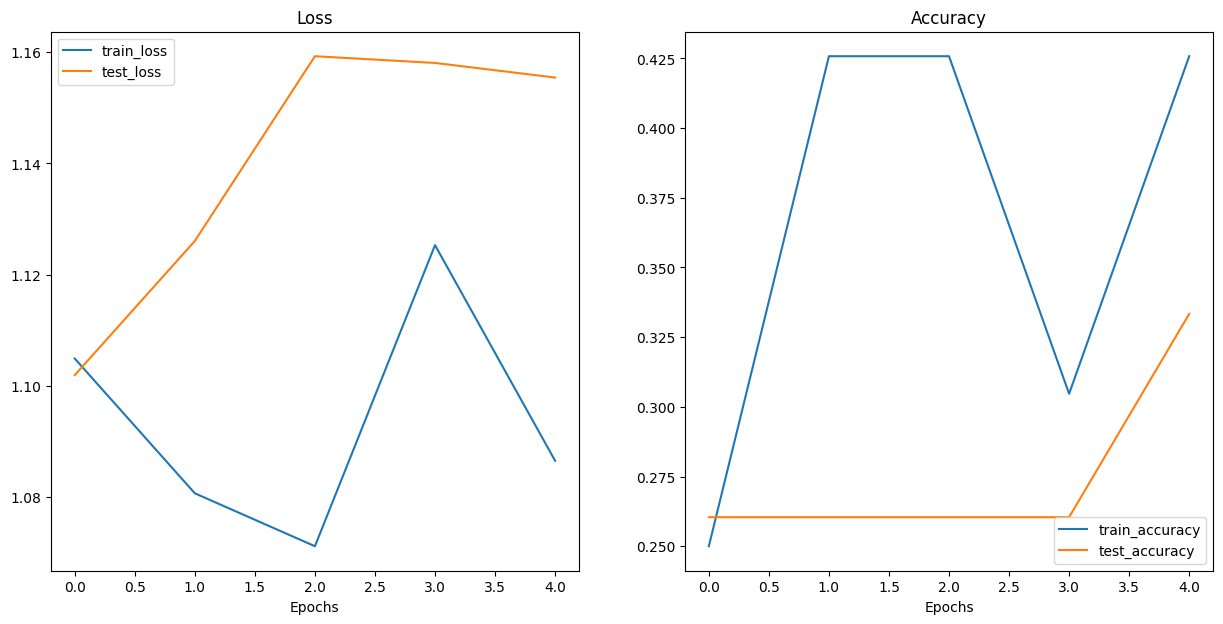

In [ ]:
plot_loss_curves(model_1_results)

### 11.4 Compare model results
There's a few different ways of doing this:
1. Hardcoding (what we have done)
2. PyTorch + TensorBoard
3. Weights and biases
4. MLFlow

In [ ]:
import pandas as pd
model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)

In [ ]:
model_0_df

,train_loss,train_acc,test_loss,test_acc
0,1.106319,0.304688,1.098321,0.301136
1,1.099806,0.328125,1.069690,0.541667
2,1.086854,0.488281,1.080757,0.492424
3,1.084233,0.398438,1.060832,0.583333
4,1.066216,0.414062,1.065396,0.564394
5,1.030505,0.433594,1.013929,0.542614
6,0.985439,0.421875,0.932304,0.593750
7,0.966324,0.578125,0.998642,0.443182
8,0.923759,0.597656,1.066946,0.332386
9,0.996855,0.464844,1.063165,0.404356


In [ ]:
model_1_df

,train_loss,train_acc,test_loss,test_acc
0,1.104914,0.250000,1.101928,0.260417
1,1.080687,0.425781,1.126056,0.260417
2,1.071172,0.425781,1.159275,0.260417
3,1.125308,0.304688,1.158067,0.260417
4,1.086534,0.425781,1.155441,0.333333


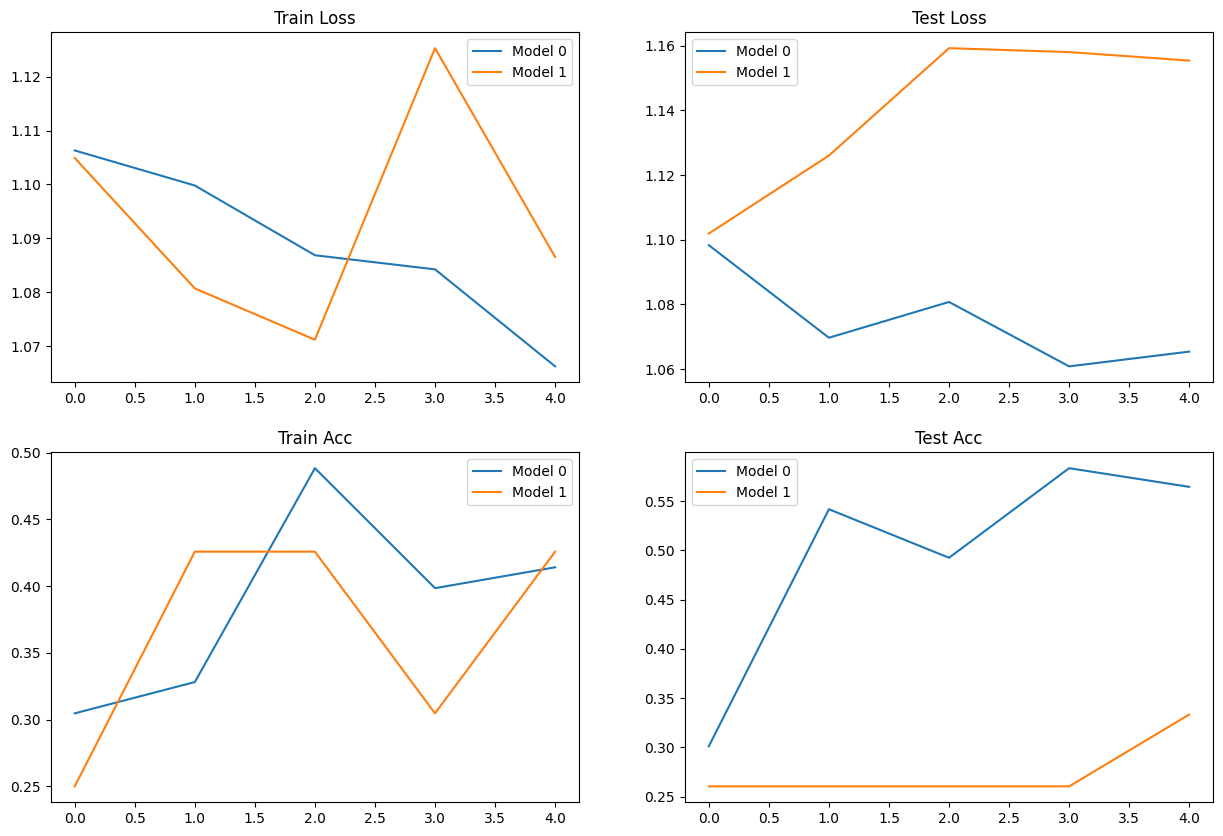

In [ ]:
# Setup a plot
plt.figure(figsize=(15,10))

# Get number of epochs
epochs = range(len(model_0_df))

# Plot train_loss
plt.subplot(2,2,1)
plt.plot(epochs,model_0_df["train_loss"],label="Model 0")
plt.plot(epochs,model_1_df["train_loss"],label="Model 1")
plt.title("Train Loss")
plt.legend()

# Plot test_loss
plt.subplot(2,2,2)
plt.plot(epochs,model_0_df["test_loss"],label="Model 0")
plt.plot(epochs,model_1_df["test_loss"],label="Model 1")
plt.title("Test Loss")
plt.legend()

# Plot train accuracy
plt.subplot(2,2,3)
plt.plot(epochs,model_0_df["train_acc"],label="Model 0")
plt.plot(epochs,model_1_df["train_acc"],label="Model 1")
plt.title("Train Acc")
plt.legend()

# Plot test accuracy
plt.subplot(2,2,4)
plt.plot(epochs,model_0_df["test_acc"],label="Model 0")
plt.plot(epochs,model_1_df["test_acc"],label="Model 1")
plt.title("Test Acc")
plt.legend()

## 12.Making a prediction on a custom image



In [ ]:
# Download a custom image
import requests

# Setup custom iamge path
custom_image_path = data_path / "04-pizza-dad.jpeg"

# Ensure the data directory exists
custom_image_path.parent.mkdir(parents=True, exist_ok=True)

# Download the image, overwriting if it already exists
print(f"Downloading {custom_image_path}...")
with open(custom_image_path,"wb") as f:
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
  f.write(request.content)
print(f"Downloaded {custom_image_path}.")

Downloaded data/04-pizza-dad.jpeg.


### 12.1 Loading in a custom image with PyTorch

We have to make sure our image is in the same format as the data our model was trained for
* In tensor from dtype (torch.float32)
* Of shape 64x64x3
* On the right device

We can read an image in PyTorch using `torchvision.io.read_image`

In [ ]:
str(custom_image_path)

'data/04-pizza-dad.jpeg'

In [ ]:
import torchvision
import torch # Import torch for dtype conversions
from torchvision import transforms

# Create transform pipeline to resize the image
custom_image_transform = transforms.Compose([
    transforms.Resize((64, 64)), # Resize the image tensor
    transforms.ConvertImageDtype(torch.float32), # Convert to float32 and scale to [0.0, 1.0]
])


custom_image_tensor_uint8 = torchvision.io.read_image(str(custom_image_path))

custom_image_tensor = custom_image_transform(custom_image_tensor_uint8)

print(f"Custom image tensor shape: {custom_image_tensor.shape}")
print(f"Custom image tensor dtype: {custom_image_tensor.dtype}")

custom_image_tensor

Custom image tensor shape: torch.Size([3, 64, 64])
Custom image tensor dtype: torch.float32


tensor([[[0.4667, 0.5294, 0.5608,  ..., 0.0980, 0.0588, 0.0588],
         [0.4000, 0.4353, 0.4275,  ..., 0.0667, 0.0706, 0.0863],
         [0.5176, 0.4863, 0.4471,  ..., 0.0627, 0.0588, 0.0706],
         ...,
         [0.2980, 0.2824, 0.2706,  ..., 0.4588, 0.4000, 0.3961],
         [0.2784, 0.2706, 0.2588,  ..., 0.4627, 0.4196, 0.3765],
         [0.2510, 0.2549, 0.2706,  ..., 0.4902, 0.6078, 0.5333]],

        [[0.4941, 0.5529, 0.5765,  ..., 0.1255, 0.0706, 0.0667],
         [0.4549, 0.4863, 0.4588,  ..., 0.0824, 0.0824, 0.1020],
         [0.5490, 0.5216, 0.4784,  ..., 0.0706, 0.0706, 0.0863],
         ...,
         [0.2078, 0.1961, 0.1882,  ..., 0.3137, 0.2784, 0.2784],
         [0.1922, 0.1882, 0.1804,  ..., 0.3216, 0.2941, 0.2667],
         [0.1725, 0.1765, 0.1882,  ..., 0.3412, 0.4235, 0.3686]],

        [[0.4510, 0.5255, 0.5608,  ..., 0.0824, 0.0392, 0.0431],
         [0.3137, 0.3608, 0.3843,  ..., 0.0510, 0.0549, 0.0784],
         [0.4784, 0.4235, 0.3961,  ..., 0.0471, 0.0471, 0.

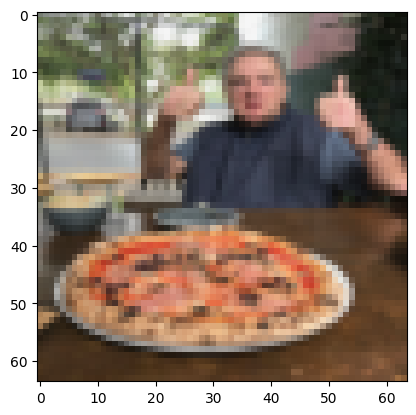

In [ ]:
plt.imshow(custom_image_tensor.permute(1,2,0))

### 12.2 Making a prediction on a custom image with PyTorch model

In [ ]:
model_1.eval()
with torch.inference_mode():
  custom_image_pred = model_1(custom_image_tensor.unsqueeze(dim=0).to(device))

custom_image_pred

tensor([[ 0.0780,  0.0379, -0.2067]])

In [ ]:
class_names

['pizza', 'steak', 'sushi']

In [ ]:
# Convert logits -> prediction probabilities
custom_image_pred_probs = torch.softmax(custom_image_pred,dim=1)
custom_image_pred_probs

tensor([[0.3686, 0.3541, 0.2773]])

In [ ]:
# Convert the pred probs -> prediction labels
custom_image_pred_label = torch.argmax(custom_image_pred_probs,dim=1).cpu()
custom_image_pred_label

tensor([0])

In [ ]:
class_names[custom_image_pred_label]

'pizza'

### 12.3 Putting custom image prediction together: building a function

Ideal outcome:
A function we pass an image path to and have our model predict the image and plot the image + prediction



In [ ]:
def pred_and_plot_image(model:torch.nn.Module,
                        image_path:str,
                        class_names: List[str]=None,
                        transform = None,
                        device=device):
  # Load the image
  target_image =  torchvision.io.read_image(str(image_path)).type(torch.float32)

  # Divide the image pixel values by 255 to get them between 0 and 1 (Probabilities)
  target_image /= 255

  #Transform id necessary
  if transform:
    target_image = transform(target_image)

    # Make sure the model i on right device
    model.to(device)

    # Turn on eval mode
    model.eval()
    with torch.inference_mode():
      # Add an extra dimension to the image (this is the batch dimesnion (our model will predict on batches on 1x image))
      target_image = target_image.unsqueeze(0)

      # Make prediction
      target_image_pred = model(target_image.to(device)) # Make sure the target image is on the right device

       # Convert logits -> prediction probabilities
      target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

      # Convert predictions probabilities -> prediction labels
      target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    # Plot the image
    plt.imshow(target_image.squeeze().permute(1,2,0)) # Remove batch direction and rearrange the shape to be HBC

    if class_names:
      title = f"Pred: {class_names[target_image_pred_label.cpu()]} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    else:
      title = f"Pred: {target_image_pred_label} | Prob: {target_image_pred_probs.max().cpu():.3f}"

    plt.title(title)
    plt.axis(False)



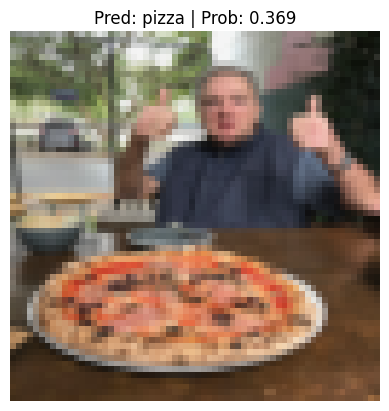

In [ ]:
pred_and_plot_image(model=model_1,
                    image_path=custom_image_path,
                    class_names=class_names,
                    transform = custom_image_transform,
                    device=device)